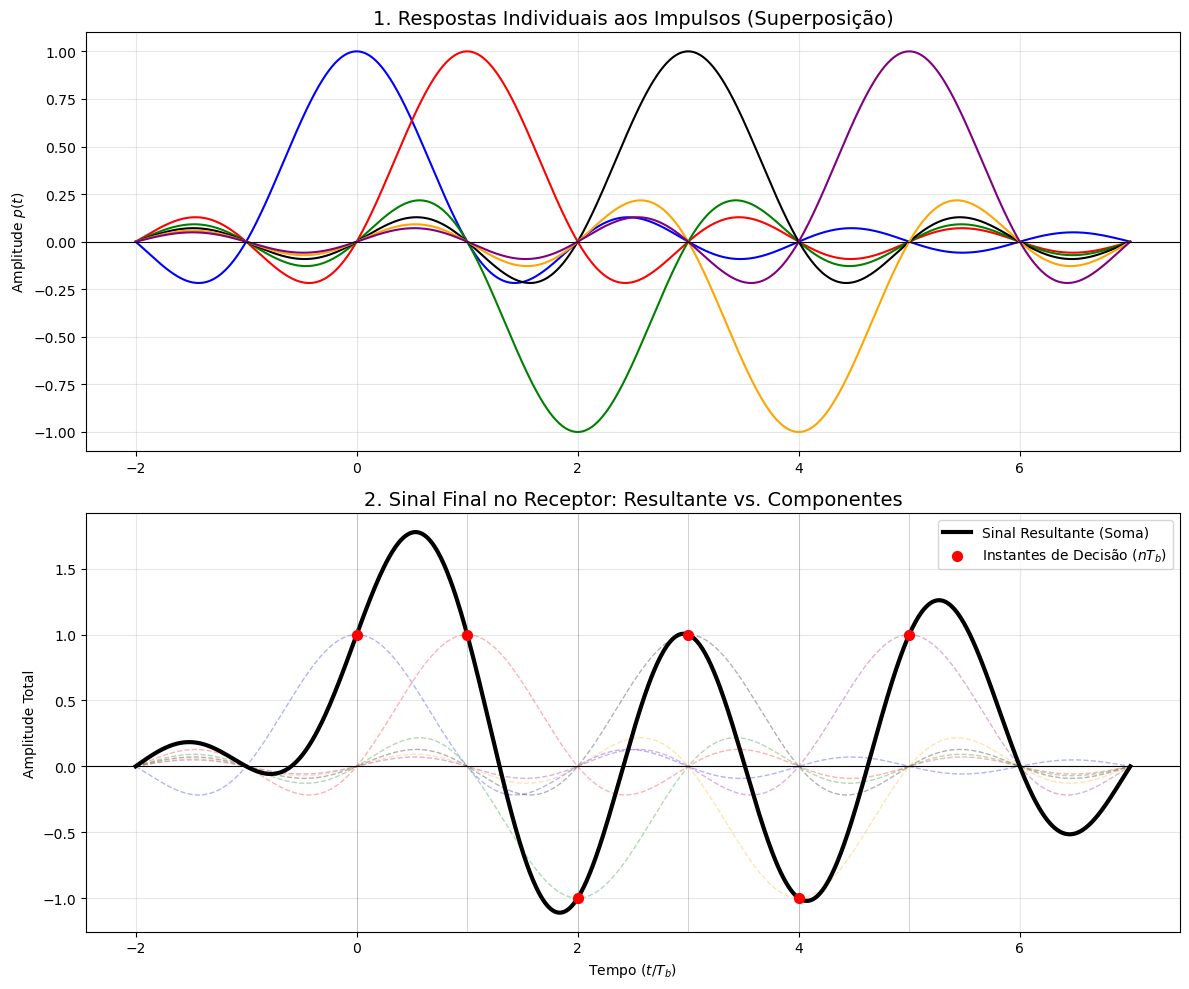

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da simulação
fs = 1000  
T = 1.0    # Período de símbolo
t = np.linspace(-2, 7, 1000) 

# Sequência de bits baseada na imagem (+1, +1, -1, +1, -1, +1)
bits = [1, 1, -1, 1, -1, 1]
offsets = np.arange(len(bits)) * T
colors = ['blue', 'red', 'green', 'black', 'orange', 'purple']

# Pulso p(t) - Sinc (Critério de Nyquist Ideal)
def p(time):
    return np.sinc(time / T)

# Cálculo das componentes
respostas_individuais = [bit * p(t - offset) for bit, offset in zip(bits, offsets)]
sinal_resultante = np.sum(respostas_individuais, axis=0)

plt.figure(figsize=(12, 10))

# --- GRÁFICO 1: APENAS INDIVIDUAIS (Como na imagem original) ---
plt.subplot(2, 1, 1)
for i, res in enumerate(respostas_individuais):
    plt.plot(t, res, color=colors[i % len(colors)], lw=1.5, label=f'Pulso {i}')
plt.axhline(0, color='black', lw=0.8)
plt.title('1. Respostas Individuais aos Impulsos (Superposição)', fontsize=14)
plt.ylabel('Amplitude $p(t)$')
plt.grid(True, alpha=0.3)

# --- GRÁFICO 2: INDIVIDUAIS + RESULTANTE EM DESTAQUE ---
plt.subplot(2, 1, 2)

# Plot das individuais com transparência (fundo)
for i, res in enumerate(respostas_individuais):
    plt.plot(t, res, color=colors[i % len(colors)], lw=1, alpha=0.3, linestyle='--')

# Plot da Resultante em destaque (frente)
plt.plot(t, sinal_resultante, color='black', lw=3, label='Sinal Resultante (Soma)')

# Pontos de amostragem (Onde a mágica do Nyquist acontece)
plt.scatter(offsets, bits, color='red', s=50, zorder=5, label='Instantes de Decisão ($nT_b$)')

# Linhas verticais nos instantes de amostragem
for offset in offsets:
    plt.axvline(offset, color='gray', lw=0.5, alpha=0.5)

plt.axhline(0, color='black', lw=0.8)
plt.title('2. Sinal Final no Receptor: Resultante vs. Componentes', fontsize=14)
plt.xlabel('Tempo ($t/T_b$)')
plt.ylabel('Amplitude Total')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()